# 01 - Analise Exploratoria do Corpus

Entender a estrutura, o vocabulario e as distribuicoes do corpus **antes** de modelar.

**Entrada:** `data/raw/` (download manual - ver [docs/DATASET.md](../docs/DATASET.md))
**Saidas:** `data/processed/data_profile.json`, graficos em `notebooks/outputs/eda/`

> Nenhuma decisao de split ou vetorizacao acontece aqui. Este notebook so observa.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Carregamento

O loader tolera variacoes de nome de coluna entre mirrors do corpus.

In [2]:
from src.data.loader import RawDataNotFoundError, load_raw

try:
    raw = load_raw()
    print(f"Documentos: {len(raw):,}")
    display(raw.head(3))
except RawDataNotFoundError as erro:
    print(erro)

Documentos: 14,438


,texto,categoria_original
0,Tissue changes around loose prostheses. A cani...,5
1,Neuropeptide Y and neuron-specific enolase lev...,1
2,"Sexually transmitted diseases of the colon, re...",2


## 2. Integridade

Nulos, duplicatas e textos degenerados.

In [3]:
diagnostico = pd.DataFrame({
    "nulos": raw.isna().sum(),
    "vazios": (raw.astype(str).apply(lambda s: s.str.strip() == "")).sum(),
})
display(diagnostico)

duplicatas = raw["texto"].duplicated().sum()
print(f"Textos duplicados: {duplicatas:,} ({duplicatas / len(raw):.2%})")

,nulos,vazios
texto,0,0
categoria_original,0,0


Textos duplicados: 3,211 (22.24%)


## 3. Distribuicao das categorias originais

O corpus rotula **condicao medica**, nao urgencia. O mapeamento para urgencia acontece no notebook 02.

,n,proporcao
categoria_original,,
1,3163,0.2191
2,1494,0.1035
3,1925,0.1333
4,3051,0.2113
5,4805,0.3328


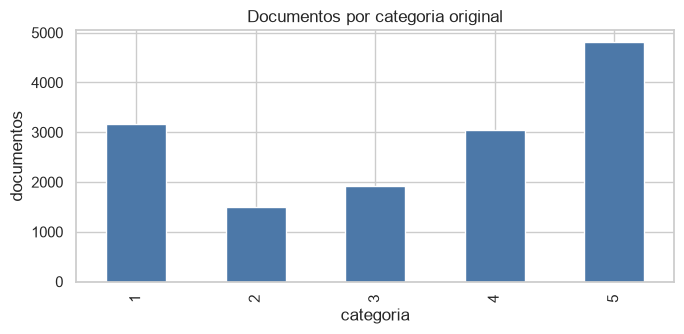

In [4]:
contagem = raw["categoria_original"].value_counts().sort_index()
proporcoes = (contagem / len(raw)).round(4)
distribuicao = pd.DataFrame({"n": contagem, "proporcao": proporcoes})
display(distribuicao)

fig, ax = plt.subplots(figsize=(7, 3.5))
contagem.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Documentos por categoria original")
ax.set_xlabel("categoria")
ax.set_ylabel("documentos")
plt.tight_layout()
plt.show()

## 4. Comprimento dos textos

Alimenta diretamente a decisao de `max_features` do TF-IDF, que e o principal fator de
latencia e de tamanho do artefato.

,caracteres,palavras
count,14438.0,14438.0
mean,1230.7,179.9
std,507.3,76.5
min,170.0,24.0
5%,439.8,61.9
50%,1210.0,176.0
95%,2050.0,302.0
99%,2594.4,383.0
max,3999.0,596.0


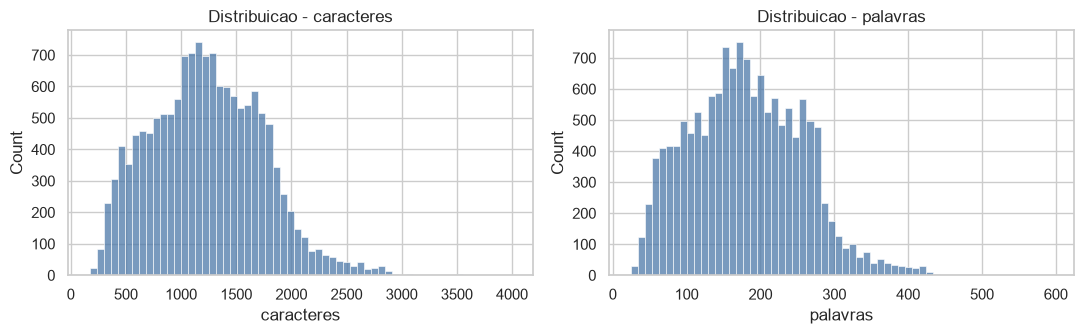

In [5]:
comprimento = pd.DataFrame({
    "caracteres": raw["texto"].str.len(),
    "palavras": raw["texto"].str.split().str.len(),
})
display(comprimento.describe(percentiles=[0.05, 0.5, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, coluna in zip(axes, comprimento.columns):
    sns.histplot(comprimento[coluna], bins=60, ax=ax, color="#4C78A8")
    ax.set_title(f"Distribuicao - {coluna}")
plt.tight_layout()
plt.show()

## 5. Textos degenerados

Quantos documentos cairiam pelo limiar minimo de caracteres configurado.

In [6]:
limiar = CONFIG["data"]["min_text_chars"]
curtos = (raw["texto"].str.len() < limiar).sum()
print(f"Limiar configurado: {limiar} caracteres")
print(f"Documentos abaixo do limiar: {curtos:,} ({curtos / len(raw):.2%})")

Limiar configurado: 30 caracteres
Documentos abaixo do limiar: 0 (0.00%)


## 6. Vocabulario

Termos mais frequentes e o peso da cauda longa.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

contador = CountVectorizer(max_features=None, min_df=2, strip_accents="unicode")
matriz = contador.fit_transform(raw["texto"])
frequencias = pd.Series(
    matriz.sum(axis=0).A1, index=contador.get_feature_names_out()
).sort_values(ascending=False)

print(f"Vocabulario (min_df=2): {len(frequencias):,} termos")
display(frequencias.head(20).to_frame("ocorrencias"))

acumulado = frequencias.cumsum() / frequencias.sum()
for cobertura in (0.5, 0.8, 0.95):
    n_termos = int((acumulado <= cobertura).sum())
    print(f"{cobertura:.0%} das ocorrencias vem de {n_termos:,} termos")

Vocabulario (min_df=2): 25,328 termos


,ocorrencias
the,122496
of,121285
and,81967
in,79379
with,43935
to,43080
patients,34444
was,28455
were,24358
for,21779


50% das ocorrencias vem de 200 termos
80% das ocorrencias vem de 1,737 termos
95% das ocorrencias vem de 7,496 termos


## 7. Perfil salvo

O `data_profile.json` alimenta o notebook 02 e serve de registro de reprodutibilidade.

In [8]:
import json

from src.config import DATA_PROCESSED, DATA_RAW, NOTEBOOK_OUTPUTS
from src.data.loader import dataset_hash

saida_eda = NOTEBOOK_OUTPUTS / "eda"
saida_eda.mkdir(parents=True, exist_ok=True)

arquivos_brutos = sorted(p for p in DATA_RAW.glob("*.csv"))
perfil = {
    "n_documentos": int(len(raw)),
    "n_categorias": int(raw["categoria_original"].nunique()),
    "distribuicao_categorias": contagem.to_dict(),
    "duplicatas": int(duplicatas),
    "comprimento_caracteres": comprimento["caracteres"].describe().round(2).to_dict(),
    "comprimento_palavras": comprimento["palavras"].describe().round(2).to_dict(),
    "vocabulario_min_df_2": int(len(frequencias)),
    "arquivos": {p.name: dataset_hash(p) for p in arquivos_brutos},
}

destino = DATA_PROCESSED / "data_profile.json"
with destino.open("w", encoding="utf-8") as handle:
    json.dump(perfil, handle, indent=2, ensure_ascii=False, default=str)
print(f"Perfil salvo em {destino}")

Perfil salvo em C:\Users\willi\OneDrive\Documentos\Estudos\Python\tc03-cloud-mlops\data\processed\data_profile.json


---

## Observacoes

_Registrar aqui o que a exploracao revelou: desbalanceamento, textos anomalos, termos
suspeitos de vazamento, decisoes que isso impoe ao notebook 02._